# Experimentation and Implementation

I plan on using this python notebook as a way to formulate how my neural networks should work. If you are reading this without having read the README.md I will quickly explain the goals of this project:

This project is meant to serve both as an introduction to protein folding via machine learning, and to test the potential strength of a relatively new algorithm named 'ProtTrans' which can take a string of protein residues and transform the input into a string that would be easier to read and train a neural network on for feasable proteins.

As a quick mark, here are the things I need to do in this file:
1) Import protein residue data
2) Processes, refine, and reduce data so that the nn can be trained quickly to experiment and adapt
3) build and train neural network that takes in residues straight.
4) incorporate ProtTrans, feed data in, and store output
5) build and train another neural network on ProtTrans output data
6) Optimize hyperparameters for both neural networks and experiment with various values like depth and # of hidden nodes.
7) print graphs and data to compare and analyize

I am not entirely sure what type of output the cnn should provide, it can either provide a 0-1 value of certainty of contact, then we use a cutoff to decide what is a contact or not, or it can provide a distance metric that we then filter to however many A we want to use to denote a "contact"


# Imports and dependencies

In [3]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available, using CPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


No GPU available, using CPU


# Importing Protein Data

I will use the following code box to try and visualize the data given in the 'adataset' pdb file. 

The key features I need to be able to extract are name, length, amino acid residues, and the contact map.

A lot of this is written in a way that should make it easy to apply this to the whole database.

4LGTD
247
['M', 'S', 'E', 'K', 'L', 'Q', 'K', 'V', 'L', 'A', 'R', 'A', 'G', 'H', 'G', 'S', 'R', 'R', 'E', 'I', 'E', 'S', 'I', 'I', 'E', 'A', 'G', 'R', 'V', 'S', 'V', 'D', 'G', 'K', 'I', 'A', 'K', 'L', 'G', 'D', 'R', 'V', 'E', 'V', 'T', 'P', 'G', 'L', 'K', 'I', 'R', 'I', 'D', 'G', 'H', 'L', 'I', 'S', 'V', 'R', 'E', 'S', 'I', 'C', 'R', 'V', 'L', 'A', 'Y', 'Y', 'K', 'P', 'E', 'G', 'E', 'L', 'C', 'T', 'R', 'N', 'D', 'P', 'E', 'G', 'R', 'P', 'T', 'V', 'F', 'D', 'R', 'L', 'P', 'K', 'L', 'R', 'G', 'A', 'R', 'W', 'I', 'A', 'V', 'G', 'R', 'L', 'D', 'V', 'N', 'T', 'X', 'G', 'L', 'L', 'L', 'F', 'T', 'T', 'D', 'G', 'E', 'L', 'A', 'N', 'R', 'L', 'M', 'H', 'P', 'S', 'R', 'E', 'V', 'E', 'R', 'E', 'Y', 'A', 'V', 'R', 'V', 'F', 'G', 'Q', 'V', 'D', 'D', 'A', 'K', 'L', 'R', 'D', 'L', 'S', 'R', 'G', 'V', 'Q', 'L', 'E', 'D', 'G', 'P', 'A', 'A', 'F', 'K', 'T', 'I', 'K', 'F', 'S', 'G', 'G', 'E', 'G', 'I', 'N', 'Q', 'W', 'Y', 'N', 'V', 'T', 'L', 'T', 'E', 'G', 'R', 'N', 'R', 'E', 'V', 'R', 'R', 'L', 'W', 'E',

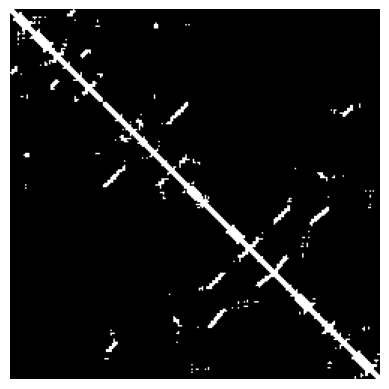

In [4]:
with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    # Extract the data we need from the slice of the dataset
    segment = list(islice(pdb_adataset, 16))
    data = {"name": [], "length": [], "proteins": [], "xyz": []}
    data["name"].append(segment[0].replace("\n", ""))
    data["length"].append(int(segment[1]))

    # protein and coords need extra care, as they are lists in the dict list
    data["proteins"].append(
        segment[2].replace("\n", "")
            .split("\t")
    )
    del data["proteins"][0][-1]

    data["xyz"].append(
        segment[13].replace("\n", "")
            .split("\t")
        )
    del data["xyz"][0][-1]

    # We are going to use a for loop to turn the xyz coordinates into floats and make the triplet lists
    i = 0
    for string in data["xyz"][0]:
        data["xyz"][0][i] = list(map(float, string.split(" ")))
        i += 1

print(data["name"][0])
print(data["length"][0])
print(data["proteins"][0])
print(len(data["proteins"][0]))
print(data["xyz"][0])
print(len(data["xyz"][0]))

# Calculating and printing the contact map
contact = []
for coord1 in data["xyz"][0]:
    temp = []
    for coord2 in data["xyz"][0]:
        distance = np.linalg.norm(np.array(coord1) - np.array(coord2))
        if (distance <= 8): val = 1
        else: val = 0
        temp.append(val)
    contact.append(temp)

def applyThreshold(tensor, threshold, length):  
    map = []
    for i, line in enumerate(tensor, 0):
        if i == length: break
        temp_line = []
        for element in line[:length]:
            if (element < threshold):
                temp_line.append(1.)
            else:
                temp_line.append(0.)
        map.append(temp_line)
    return map

def printMap(map, size = -1):
    if size > 0:
        newMap = map[:size, :size]
    else:
        newMap = map
    fig, ax = plt.subplots()
    ax.imshow(np.matrix(newMap), cmap='gray')
    ax.axis('off')
    plt.show()

printMap(contact)

## Loading in data from dataset

This is a large text box, though its functionality is not complicated. The class loads in the data from the file, then encodes the protein resiude list using VHSE encodings, which are then concatenated into pairs to represent the tensors, the train tensors are a Length x Length grid of vectors of length 16 (8 per residue in each pair). The test data takes the coordinates given by the database to make a tensor of L x L with each value being the distance between each protein (as seen above)

Previously calculated statistics:

Max length:  1195 	Min length:  30 	Mean length:  219.79 	Mode length:  233

Chars used in proteins:  {'N', 'F', 'P', 'A', 'D', 'M', 'T', 'G', 'Q', 'H', 'I', 'K', 'W', 'Y', 'X', 'V', 'S', 'E', 'C', 'R', 'L'} 	Count:  21

In [5]:
from tqdm import tqdm
import os.path

MAXLENGTH = 200

# I am adding this so I can press "Run all" and have it skip this if not necessary
if not os.path.isfile("pdb-encodings-"):
    vhse_map = {
        'A': [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48],
        'R': [-1.47, 1.45, 1.24, 1.27, 1.55, 1.47, 1.3, 0.83],
        'N': [-0.99, 0, -0.37, 0.69, -0.55, 0.85, 0.74, -0.8],
        'D': [-1.15, 0.67, -0.41, -0.01, -2.68, 1.31, 0.03, 0.56],
        'C': [0.18, -1.67, -0.46, -0.21, 0, 1.2, -1.61, -0.19],
        'Q': [-0.96, 0.12, 0.18, 0.16, 0.09, 0.42, -0.2, -0.41],
        'E': [-1.18, 0.4, 0.1, 0.36, -21.6, -0.17, 0.91, 0.02],
        'G': [-0.2, -1.53, -2.63, 2.28, -0.53, -1.18, 2.01, -1.34],
        'H': [-0.43, -0.25, 0.37, 0.19, 0.51, 1.28, 0.93, 0.65],
        'I': [1.27, -0.14, 0.3, -1.8, 0.3, -1.61, -0.16, -0.13],
        'L': [1.36, 0.07, 0.26, -0.8, 0.22, -1.37, 0.08, -0.62],
        'K': [-1.17, 0.7, 0.7, 0.8, 1.64, 0.67, 1.63, 0.13],
        'M': [1.01, -0.53, 0.43, 0, 0.23, 0.1, -0.86, -0.68],
        'F': [1.52, 0.61, 0.96, -0.16, 0.25, 0.28, -1.33, -.02],
        'P': [0.22, -0.17, -0.5, 0.05, -0.01, -1.34, -0.19, 3.56],
        'S': [-0.67, -0.88, -1.07, -0.41, -0.32, 0.27, -0.64, 0.11],
        'T': [-0.34, -0.51, -0.55, -1.06, 0.01, -0.01, -0.79, 0.39],
        'W': [1.5, 2.06, 1.79, 0.75, 0.75, -0.13, -1.06, -0.85],
        'Y': [0.61, 1.6, 1.17, 0.73, 0.53, 0.25, -0.96, -0.52],
        'V': [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03],
        'X': [0, 0, 0, 0, 0, 0, 0, 0],
    }

    # Read in data from the two files
    print("Reading in from dataset files")

    with open("pdb.fasta_qual.16Nov2022_30.fasta") as pdb_fasta:
        fasta_lines = pdb_fasta.readlines()[0::2]
    fasta_lines = [s.replace('>', '') for s in fasta_lines]
    fasta_lines = [s.replace('\n', '') for s in fasta_lines]

    data = {"name": [], "length": [], "proteins": [], "coord": []}
    i = 0

    with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
        while True:
            segment = list(islice(pdb_adataset, 16))
            if not segment: # If there are no more lines we break the loop.
                break

            name = segment[0].replace("\n", "")
            if name in fasta_lines:
                length = int(segment[1])
                if (length <= MAXLENGTH):
                    data["name"].append(name)
                    data["length"].append(length)

                    # Residue data
                    proteins = segment[2].replace("\n", "").split("\t")
                    del proteins[-1]
                    data["proteins"].append(proteins)

                    # Coordinate data
                    coords = segment[13].replace("\n", "").split("\t")
                    del coords[-1]

                    i = 0
                    for string in coords:
                        coords[i] = list(map(float, string.split(" ")))
                        i += 1
                    data["coord"].append(coords) 
    print("Finished reading from files.")   

    # Pad coordinates to MAXLENGTH
    # print("Extending coordinates to MAXLENGTH")
    # for protein in tqdm(data['coord']):
    #     while len(protein) < MAXLENGTH:
    #         protein.append([0.0, 0.0, 0.0])

    # Convert proteins to encodings
    print("Encoding protein residues")
    encoded_prots = []
    for protein in tqdm(data['proteins']):
        temp_encoding = []
        for residue in protein:
            temp_encoding.append(vhse_map[residue])
        while len(temp_encoding) < MAXLENGTH:
            # Normalize the encoded lengths to MAXLENGTH
            temp_encoding.append([0, 0, 0, 0, 0, 0, 0, 0])

        encoded_prots.append(temp_encoding)
            
    data['encoded'] = encoded_prots
    print("Finished encoding protein residues")

    print(f"Name: {data['name'][0]} \tLength: {data['length'][0]} \nResidue Chain: {data['proteins'][0]} \nEncodings: {data['encoded'][0]} \nCoordinates: {data['coord'][0]}")

Reading in from dataset files
Finished reading from files.
Encoding protein residues


100%|██████████| 14177/14177 [00:00<00:00, 44739.60it/s]

Finished encoding protein residues
Name: 2KL1A 	Length: 87 
Residue Chain: ['M', 'N', 'E', 'A', 'K', 'G', 'V', 'Y', 'V', 'M', 'S', 'V', 'L', 'P', 'N', 'M', 'P', 'A', 'A', 'G', 'R', 'L', 'E', 'A', 'G', 'D', 'R', 'I', 'A', 'A', 'I', 'D', 'G', 'Q', 'P', 'I', 'N', 'T', 'S', 'E', 'Q', 'I', 'V', 'S', 'Y', 'V', 'R', 'E', 'K', 'Q', 'A', 'G', 'D', 'R', 'V', 'R', 'V', 'T', 'F', 'I', 'R', 'D', 'R', 'K', 'Q', 'H', 'E', 'A', 'E', 'L', 'V', 'L', 'K', 'P', 'F', 'P', 'H', 'H', 'P', 'N', 'Q', 'I', 'G', 'L', 'G', 'V', 'T'] 
Encodings: [[1.01, -0.53, 0.43, 0, 0.23, 0.1, -0.86, -0.68], [-0.99, 0, -0.37, 0.69, -0.55, 0.85, 0.74, -0.8], [-1.18, 0.4, 0.1, 0.36, -21.6, -0.17, 0.91, 0.02], [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48], [-1.17, 0.7, 0.7, 0.8, 1.64, 0.67, 1.63, 0.13], [-0.2, -1.53, -2.63, 2.28, -0.53, -1.18, 2.01, -1.34], [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03], [0.61, 1.6, 1.17, 0.73, 0.53, 0.25, -0.96, -0.52], [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03], [1.01, -0

In [6]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import linecache
import ast

class vhseDataset(Dataset):
    def __init__(self, num_data = -1, test = False):
        self.length = 0
        if test:
            self.file = f"pdb-vhsetest{num_data}"
        else:
            self.file = f"pdb-vhse{num_data}"
        # Check to see if the necessary file exists, if it doesn't, create it
        if not os.path.isfile(self.file):
            # Here is where we load the actual data, based on whether its a test set or not
            if num_data >= 1:
                if test:
                    dataset = {key: value[-num_data:] for key, value in data.items()}
                else:
                    dataset = {key: value[:num_data] for key, value in data.items()}
            else:
                dataset = data
                
            # Convert encoded proteins into tensors - we are going to try and use (protein1, protein2, protein1-protein2, protein1+protein2)
            with open(self.file, 'x') as pdb:
                for i, protein in enumerate(tqdm(dataset['encoded'])):
                    pdb.write(f"{protein}\n")

                    length = dataset['length'][i]
                    
                    # Convert residue coords to distances
                    protein = dataset['coord'][i]
                    protein = np.array(protein)
                    tensor = protein[:, None, :] - protein[None, :, :]
                    tensor = np.linalg.norm(tensor, axis=2)
                    tensor = applyThreshold(tensor, 8, length)
                    pdb.write(f"{tensor}\n")

                    pdb.write(f"{length}\n")

                    self.length += 1

        else:
            with open(self.file) as pdb:
                self.length = int(sum(1 for line in pdb) / 3)
    
    def __len__(self):
        return self.length
    
    # I have made this a drive-read class for memory reasons, it will be much slower but hopefully wont consume over 32gb of memory
    def __getitem__(self, index):
        f_i = (index * 3) + 1

        # Import and adjust encodings
        line = linecache.getline(self.file, f_i)
        protein = line.replace("\n", "")
        protein = np.array(ast.literal_eval(protein))
        protein = np.float32(protein)
        tensor = np.concatenate([
                    protein[:, None, :] + np.zeros_like(protein[None, :, :]),  # broadcast feat_i
                    protein[None, :, :] + np.zeros_like(protein[:, None, :]),  # broadcast feat_j
                    protein[:, None, :] - protein[None, :, :],                 # difference
                    protein[:, None, :] * protein[None, :, :]
                    ], axis=-1)
        tensor = torch.tensor(tensor)
        tensor = tensor.permute(2, 0, 1)
        tensor = torch.nn.functional.normalize(tensor)

        # Import length
        line = linecache.getline(self.file, f_i + 2)
        length = line.replace("\n", "")
        length = np.int64(length)

        # Import coordinate map
        line = linecache.getline(self.file, f_i + 1)
        map = line.replace("\n", "")
        map = np.array(ast.literal_eval(map))
        map = np.pad(map, [(0, MAXLENGTH-length), (0, MAXLENGTH-length)])
        map = np.float32(map)
        map = torch.tensor(map).unsqueeze(0)

        linecache.checkcache()

        return tensor, map, length

## ProtTrans encoding dataset

In [7]:
# Embedding generation from ProtTrans Colab: https://colab.research.google.com/drive/1TUj-ayG3WO52n5N50S7KH9vtt6zRkdmj?usp=sharing#scrollTo=nK4hwGggR_Rs 
import h5py
import time
from transformers import T5EncoderModel, T5Tokenizer

def get_T5_model():
    model = T5EncoderModel.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc")
    model = model.to(device) # move model to GPU
    model = model.eval() # set model to evaluation model
    tokenizer = T5Tokenizer.from_pretrained('Rostlab/prot_t5_xl_half_uniref50-enc', do_lower_case=False)

    return model, tokenizer

#@title Generate embeddings. { display-mode: "form" }
# Generate embeddings via batch-processing
# per_residue indicates that embeddings for each residue in a protein should be returned.
# per_protein indicates that embeddings for a whole protein should be returned (average-pooling)
# max_residues gives the upper limit of residues within one batch
# max_seq_len gives the upper sequences length for applying batch-processing
# max_batch gives the upper number of sequences per batch
def get_embeddings( model, tokenizer, seqs, per_residue, per_protein,
                   max_residues=4000, max_seq_len=1000, max_batch=100 ):

    results = {"residue_embs" : dict(),
               "protein_embs" : dict(),
               "sec_structs" : dict()
               }

    # sort sequences according to length (reduces unnecessary padding --> speeds up embedding)
    seq_dict   = sorted( seqs.items(), key=lambda kv: len( seqs[kv[0]] ), reverse=True )
    start = time.time()
    batch = list()
    for seq_idx, (pdb_id, seq) in enumerate(seq_dict,1):
        seq = seq
        seq_len = len(seq)
        seq = ' '.join(list(seq))
        batch.append((pdb_id,seq,seq_len))

        # count residues in current batch and add the last sequence length to
        # avoid that batches with (n_res_batch > max_residues) get processed
        n_res_batch = sum([ s_len for  _, _, s_len in batch ]) + seq_len
        if len(batch) >= max_batch or n_res_batch>=max_residues or seq_idx==len(seq_dict) or seq_len>max_seq_len:
            pdb_ids, seqs, seq_lens = zip(*batch)
            batch = list()

            # add_special_tokens adds extra token at the end of each sequence
            #token_encoding = tokenizer.batch_encode_plus(seqs, add_special_tokens=True, padding="longest")
            token_encoding = tokenizer(seqs, padding="longest", add_special_tokens=True, return_tensors="pt")
            input_ids      = torch.tensor(token_encoding['input_ids']).to(device)
            attention_mask = torch.tensor(token_encoding['attention_mask']).to(device)

            try:
                with torch.no_grad():
                    # returns: ( batch-size x max_seq_len_in_minibatch x embedding_dim )
                    embedding_repr = model(input_ids, attention_mask=attention_mask)
            except RuntimeError:
                print("RuntimeError during embedding for {} (L={})".format(pdb_id, seq_len))
                continue


            for batch_idx, identifier in enumerate(pdb_ids): # for each protein in the current mini-batch
                s_len = seq_lens[batch_idx]
                # slice off padding --> batch-size x seq_len x embedding_dim
                emb = embedding_repr.last_hidden_state[batch_idx,:s_len]
                if per_residue: # store per-residue embeddings (Lx1024)
                    results["residue_embs"][ identifier ] = emb.detach().cpu().numpy().squeeze()
                if per_protein: # apply average-pooling to derive per-protein embeddings (1024-d)
                    protein_emb = emb.mean(dim=0)
                    results["protein_embs"][identifier] = protein_emb.detach().cpu().numpy().squeeze()


    passed_time=time.time()-start
    avg_time = passed_time/len(results["residue_embs"]) if per_residue else passed_time/len(results["protein_embs"])
    print('\n############# EMBEDDING STATS #############')
    print('Total number of per-residue embeddings: {}'.format(len(results["residue_embs"])))
    print('Total number of per-protein embeddings: {}'.format(len(results["protein_embs"])))
    print("Time for generating embeddings: {:.1f}[m] ({:.3f}[s/protein])".format(
        passed_time/60, avg_time ))
    print('\n############# END #############')
    return results

c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
class ptDataset(Dataset):

    def __init__(self, data, num_data = -1, test = False):
        self.length = 0
        if test:
            self.file = f"pdb-pttest{num_data}"
        else:
            self.file = f"pdb-pt{num_data}"
        
        # If there is not a file with this name, then we need to create it
        if not os.path.isfile(self.file):
            if num_data >= 1:
                if test:
                    dataset = {key: value[-num_data:] for key, value in data.items()}
                else:
                    dataset = {key: value[:num_data] for key, value in data.items()}
            else:
                dataset = data
            
            # We need to convert the data to a dictionary that the prot-trans method can read
            # This should maintain order, so I can still use dataset
            sequences = {key: value for key, value in zip(dataset['name'], dataset['proteins'])}
            
            with open(self.file, 'x') as pdb:
                model, tokenizer = get_T5_model()
                # I am not sure how to implement the 1024x1 protein-embedding vector, so we will avoid it for now
                results = get_embeddings(model, tokenizer, sequences, True, False)
                for i, data in enumerate(tqdm(results['residue_embs'].items())):
                    key, value = data

                    length = dataset['length'][i]
                    pdb.write(f"{length}\n")

                    pdb.write(f"{np.ndarray.tolist(value)}\n")

                    # Convert residue coords to distances
                    protein = dataset['coord'][i]
                    protein = np.array(protein)
                    tensor = protein[:, None, :] - protein[None, :, :]
                    tensor = np.linalg.norm(tensor, axis=2)
                    tensor = applyThreshold(tensor, 8, length)
                    pdb.write(f"{tensor}\n")

                    

                    self.length += 1
                    
        else:
            with open(self.file) as pdb:
                self.length = int(sum(1 for line in pdb) / 3)
                
                

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        f_i = (index * 3) + 1

        # Import length
        line = linecache.getline(self.file, f_i)
        print(line)
        length = line.replace("\n", "")
        length = np.int64(length)

        # Import and adjust encodings
        line = linecache.getline(self.file, f_i + 1)
        print(line)
        protein = line.replace("\n", "")
        protein = np.array(ast.literal_eval(protein))
        protein = np.pad(protein, [(0, MAXLENGTH-length), (0, 0)])
        protein = np.float32(protein)
        tensor = np.concatenate([
                    protein[:, None, :] + np.zeros_like(protein[None, :, :]),  # first embedding
                    protein[None, :, :] + np.zeros_like(protein[:, None, :]),  # second embedding
                    protein[:, None, :] - protein[None, :, :],                 # difference
                    protein[:, None, :] * protein[None, :, :]                  # sum
                    ], axis=-1)
        tensor = torch.tensor(tensor)
        tensor = tensor.permute(2, 0, 1)
        tensor = torch.nn.functional.normalize(tensor)

        # Import coordinate map
        line = linecache.getline(self.file, f_i + 2)
        print(line)
        map = line.replace("\n", "")
        map = np.array(ast.literal_eval(map))
        map = np.pad(map, [(0, MAXLENGTH-length), (0, MAXLENGTH-length)])
        map = np.float32(map)
        map = torch.tensor(map).unsqueeze(0)

        linecache.checkcache()

        return tensor, map, length


## Creating Train & Test datasets

In [9]:
batch = 500
count = 2  # -1 Does all data
train_data = vhseDataset(num_data = count)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_data = vhseDataset(num_data = count, test = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle=True)

## Visualize vhse data to ensure class functionalitiy

torch.Size([2, 32, 200, 200])
tensor([[ 0.0664, -0.0000, -0.0664,  ..., -0.0000, -0.0000, -0.0000],
        [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0501,  0.0000,  0.0501,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])


c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchshow\visualization.py:385: UserWarning: Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.
  warnings.warn('Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.')


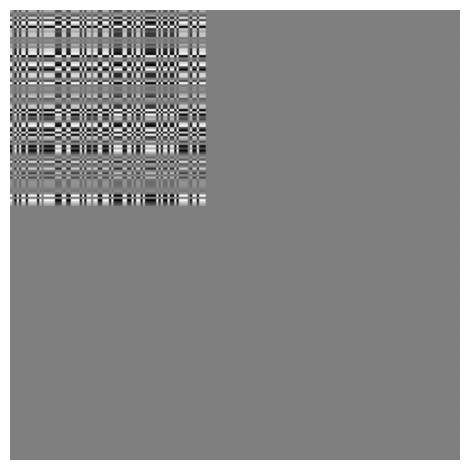

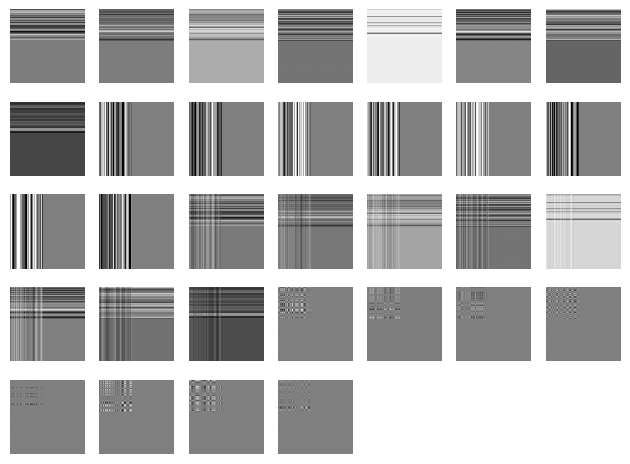

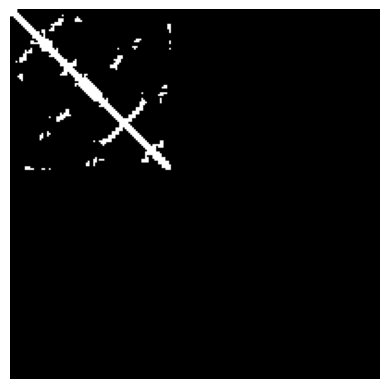

tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


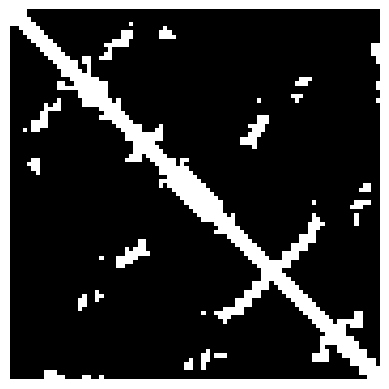

In [10]:
import torchshow
trainiter = iter(train_loader)

# Train data
train, target, length = next(trainiter)
print(train.shape)
train = train.squeeze(0)
torchshow.show(train[0][25])
print(f"{train[0][25]}")
# This doesn't look how I expected it to, but the printed tensor does
torchshow.show(train[0])

# Target data
target = target[0]
#print(target)
printMap(target.squeeze(0))
print(target)
printMap(target.squeeze(0), length[0])

## Visualize pt data

In [18]:
batch = 500
count = 2  # -1 Does all data
train_data_pt = ptDataset(data, num_data = count)
train_loader_pt = DataLoader(dataset = train_data_pt, batch_size = batch, shuffle = True)
test_data_pt = ptDataset(data, num_data = count, test = True)
test_loader_pt = DataLoader(dataset = test_data_pt, batch_size = batch, shuffle=True)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Rostlab/prot_t5_xl_half_uniref50-enc/94a6abc029ae13029317b140b7424e012bf8dfbf/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Rostlab/pro


############# EMBEDDING STATS #############
Total number of per-residue embeddings: 2
Total number of per-protein embeddings: 0
Time for generating embeddings: 0.3[m] (7.678[s/protein])

############# END #############


100%|██████████| 2/2 [00:00<00:00, 18.87it/s]
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Rostlab/prot_t5_xl_half_uniref50-enc/94a6abc029ae13029317b140b7424e012bf8dfbf/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Rostlab/prot_t5_xl_half_uniref50-enc/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
Loading weights: 100%|██████


############# EMBEDDING STATS #############
Total number of per-residue embeddings: 2
Total number of per-protein embeddings: 0
Time for generating embeddings: 0.3[m] (9.396[s/protein])

############# END #############


100%|██████████| 2/2 [00:00<00:00, 13.80it/s]


In [19]:
import torchshow

# Train data
train, target, length = train_data_pt[0]
print(train.shape)
train = train.squeeze(0)
torchshow.show(train[0][25])
print(f"{train[0][25]}")
# This doesn't look how I expected it to, but the printed tensor does
torchshow.show(train[0])

# Target data
target = target[0]
#print(target)
printMap(target.squeeze(0))
print(target)
printMap(target.squeeze(0), length[0])

[[-0.3681640625, -0.267822265625, 0.10003662109375, 0.0972900390625, -0.0765380859375, -0.169189453125, -0.1024169921875, -0.468017578125, 0.0770263671875, -0.0181427001953125, -0.13916015625, 0.1688232421875, 0.10089111328125, 0.091796875, 0.0179901123046875, 0.1539306640625, 0.002132415771484375, 0.11920166015625, 0.245361328125, 0.032073974609375, -0.0631103515625, -0.1590576171875, -0.10662841796875, -0.0189971923828125, -0.273681640625, 0.0036945343017578125, -0.1763916015625, -0.150146484375, 0.272705078125, 0.273681640625, 0.2060546875, 0.220703125, -0.176025390625, -0.30517578125, -0.09564208984375, -0.188720703125, -0.0194091796875, -0.143310546875, -0.20263671875, 0.112060546875, 0.149169921875, -0.016632080078125, 0.205322265625, -0.0531005859375, -0.2646484375, 0.143798828125, 0.278076171875, -0.0273284912109375, 0.069580078125, -0.134521484375, -0.345458984375, 0.0643310546875, -0.02203369140625, 0.0828857421875, 0.1275634765625, 0.2059326171875, -0.0816650390625, -0.17993

ValueError: invalid literal for int() with base 10: '[[-0.3681640625, -0.267822265625, 0.10003662109375, 0.0972900390625, -0.0765380859375, -0.169189453125, -0.1024169921875, -0.468017578125, 0.0770263671875, -0.0181427001953125, -0.13916015625, 0.1688

# Creating a Convolutional Neural Network

In [ ]:
class CNN(nn.Module):
    def _init_(self, feat, channels):
        super(CNN, self)._init_()

        self.prime = nn.Sequential(
            nn.Conv2d(feat, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(channels)
        )
        self.hidden = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(channels)
        )
        self.final = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        x = self.prime(x)
        x = self.hidden(x)
        x = self.final(x)
        
        return x

## Testing CNN forward to confirm data works

In [ ]:
# import torch.optim as optim

# vhse_cnn = CNN(32, 32)
# train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
# trainiter = iter(train_loader)

# tensor, label, length = next(trainiter) 
# out_vhse = vhse_cnn(tensor)
# print(out_vhse.shape)
# out_vhse = out_vhse[0].squeeze(0).squeeze(0)
# print(out_vhse)
# printMap(out_vhse.detach().numpy())

## Training CNN on test data

In [ ]:
model = CNN(32, 32)

# Worth trying Adam, Adagrad, and averaged SGD
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle = True)
BCELoss = nn.BCEWithLogitsLoss()

def masked_loss(input, label, lengths):
    loss = BCELoss(input, label)

    # This will hopefully make it so the NN loss is only applied where there is no padding.
    masks = []
    for l in lengths:
        mask = torch.zeros((MAXLENGTH, MAXLENGTH))
        mask[:l, :l] = 1
        masks.append(mask)
    
    loss = loss * mask
    return loss.sum() / mask.sum()

def one_epoch(index):
    running_loss = 0
    last_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        inputs, targets, length = data

        if torch.isnan(inputs).any() or torch.isinf(inputs).any():
            print('Invalid input at batch', i)
            continue

        outputs = model(inputs)

        loss = masked_loss(outputs, targets, length)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()
        if True:
            last_loss = running_loss # loss per batch
            print(f'  batch {i+1} loss: {last_loss}')
            tb_x = index * len(train_loader) + i + 1
            running_loss = 0.
        
    return last_loss

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
epoch_number = 0

EPOCHS = 20

best_vloss = 1000000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)

    avg_loss = one_epoch(epoch_number)
    running_vloss = 0.0
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(test_loader, 1):
            vinputs, vlabels, vlength = vdata
            voutputs = model(vinputs)
            vloss = masked_loss(voutputs, vlabels, vlength)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)

    epoch_number += 1

EPOCH 1:
  batch 1 loss: 0.7640217542648315
  batch 2 loss: 0.7545832991600037
  batch 3 loss: 0.7402269840240479
  batch 4 loss: 0.7189112901687622
  batch 5 loss: 0.6997856497764587
  batch 6 loss: 0.6829559206962585
  batch 7 loss: 0.6601311564445496
  batch 8 loss: 0.6417140960693359
  batch 9 loss: 0.617195188999176
  batch 10 loss: 0.6059250831604004
  batch 11 loss: 0.5913988351821899
  batch 12 loss: 0.5782352089881897
  batch 13 loss: 0.5568161010742188
  batch 14 loss: 0.5533340573310852
  batch 15 loss: 0.5435556769371033
  batch 16 loss: 0.5274785161018372
  batch 17 loss: 0.5206878781318665
  batch 18 loss: 0.507969319820404
  batch 19 loss: 0.5030412673950195
  batch 20 loss: 0.5003594160079956
  batch 21 loss: 0.49057579040527344
  batch 22 loss: 0.47847649455070496
  batch 23 loss: 0.4699855446815491
  batch 24 loss: 0.4696783721446991
  batch 25 loss: 0.46210363507270813
  batch 26 loss: 0.4518570005893707
  batch 27 loss: 0.44199275970458984
  batch 28 loss: 0.4387846

KeyboardInterrupt: 

torch.Size([500, 1, 300, 300])
[[ 0.73945445  1.1201885   1.5917658  ...  0.9779839   0.9649971
   0.5061725 ]
 [ 0.9727753   1.0345281   1.621155   ...  0.17960447 -0.16468735
  -0.05996824]
 [ 1.4578327   1.6910673   1.6936994  ...  0.8861359   0.45806485
   0.4082553 ]
 ...
 [ 0.48806334  0.48935995  1.2928061  ... -2.356275   -2.3498716
  -1.5684355 ]
 [ 0.22474489  0.1955815   1.0095965  ... -2.3590772  -2.3593044
  -1.5737185 ]
 [ 0.32246846  0.4716191   0.6933339  ... -1.6092994  -1.6076416
  -0.97891617]]


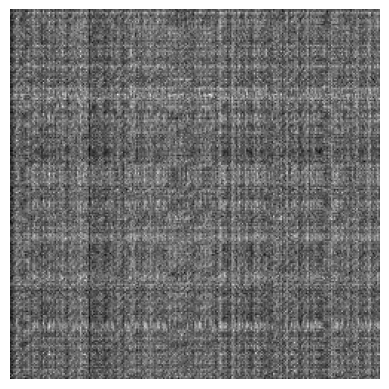

In [ ]:
testiter = iter(test_loader)

tensor, label, length = next(testiter) 
out_vhse = model(tensor)
print(out_vhse.shape)
out_vhse = out_vhse[0].squeeze(0).detach().numpy()
print(out_vhse)
printMap(out_vhse, length[0])